In [1]:
import torch, sys
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy

sys.path.append('/kaggle/input')
from scriptsfl.data_utils import load_dataset, create_dirichlet_split, get_dataloaders
from scriptsfl.models import get_model
from scriptsfl.federated_utils import get_model_weights, set_model_weights, evaluate_model
from scriptsfl.server import Server
from scriptsfl.results_utils import save_results, plot_comparison, print_summary

torch.manual_seed(42)
np.random.seed(42)

In [17]:
print("="*80)
print("TASK 4.2: SCAFFOLD IMPLEMENTATION")
print("="*80)

#%% Configuration
CONFIG = {
    'dataset': 'cifar10',
    'num_clients': 5,
    'num_rounds': 20,
    'local_epochs': 5,
    'batch_size': 32,
    'lr_local': 0.01,
    'lr_global': 1.0,
    'momentum': 0.0,  # SCAFFOLD typically uses momentum=0
    'alpha': 0.1,  # High heterogeneity
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

#%% Load non-IID data (same as Task 4.1)
train_dataset, test_dataset = load_dataset(CONFIG['dataset'])
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

client_indices = create_dirichlet_split(train_dataset, CONFIG['num_clients'], alpha=CONFIG['alpha'])
client_loaders = get_dataloaders(train_dataset, client_indices, batch_size=CONFIG['batch_size'])

TASK 4.2: SCAFFOLD IMPLEMENTATION


In [23]:
class FedProxClient:
    """
    FedProx Client with proximal term regularization
    """

    def __init__(self, client_id, data_loader, model, device='cpu'):
        self.client_id = client_id
        self.data_loader = data_loader
        self.device = device
        self.model = copy.deepcopy(model).to(device)
        self.data_size = len(data_loader.dataset)
        self.global_weights = None  # Store global weights for proximal term

    def train_local(self, epochs, lr, mu, momentum=0.9):
        """
        Train locally with FedProx proximal term

        Args:
            epochs: number of local epochs
            lr: learning rate
            mu: proximal term coefficient
            momentum: SGD momentum

        Returns:
            dict with training stats
        """
        self.model.train()
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.SGD(self.model.parameters(), lr=lr, momentum=momentum)

        # Store global weights at the start of this round
        if self.global_weights is None:
            self.global_weights = get_model_weights(self.model)

        epoch_losses = []

        for epoch in range(epochs):
            running_loss = 0.0
            for data, target in self.data_loader:
                data, target = data.to(self.device), target.to(self.device)

                optimizer.zero_grad()
                output = self.model(data)

                # Standard loss
                loss = criterion(output, target)

                # Add proximal term: (mu/2) * ||w - w_global||^2
                if mu > 0:
                    proximal_term = 0.0
                    for param, global_param in zip(self.model.parameters(), self.global_weights):
                        proximal_term += torch.norm(param - global_param.to(self.device)) ** 2
                    loss += (mu / 2) * proximal_term

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * data.size(0)

            epoch_loss = running_loss / self.data_size
            epoch_losses.append(epoch_loss)

        stats = {
            'client_id': self.client_id,
            'epochs': epochs,
            'final_loss': epoch_losses[-1],
            'epoch_losses': epoch_losses
        }

        return stats

    def get_weights(self):
        return get_model_weights(self.model)

    def set_weights(self, weights):
        set_model_weights(self.model, weights)
        self.global_weights = [w.clone() for w in weights]  # Update global weights

    def get_data_size(self):
        return self.data_size


#%% FedProx Server (modified to use FedProx clients)

class FedProxServer(Server):
    """
    Server for FedProx (uses FedProx clients)
    """

    def train_round(self, local_epochs, lr, mu, client_fraction=1.0, momentum=0.9):
        """
        Execute one round of FedProx training
        """
        # Select clients
        selected_clients = self.select_clients(fraction=client_fraction)

        # Broadcast global model
        self.broadcast_weights(selected_clients)

        # Local training with proximal term
        client_stats = []
        for client in selected_clients:
            stats = client.train_local(epochs=local_epochs, lr=lr, mu=mu, momentum=momentum)
            client_stats.append(stats)

        # Aggregate
        divergence = self.aggregate(selected_clients)

        # Evaluate
        test_acc, test_loss = self.evaluate()
        avg_train_loss = np.mean([s['final_loss'] for s in client_stats])

        round_stats = {
            'test_accuracy': test_acc,
            'test_loss': test_loss,
            'train_loss': avg_train_loss,
            'divergence': divergence,
            'num_clients': len(selected_clients)
        }

        return round_stats

    def train(self, num_rounds, local_epochs, lr, mu, client_fraction=1.0, momentum=0.9, verbose=True):
        """
        Train for multiple rounds with FedProx
        """
        for round_idx in range(num_rounds):
            round_stats = self.train_round(local_epochs, lr, mu, client_fraction, momentum)

            # Update history
            self.history['rounds'].append(round_idx + 1)
            self.history['test_accuracy'].append(round_stats['test_accuracy'])
            self.history['test_loss'].append(round_stats['test_loss'])
            self.history['train_loss'].append(round_stats['train_loss'])
            self.history['divergence'].append(round_stats['divergence'])

            if verbose:
                print(f"Round {round_idx + 1}/{num_rounds} | "
                      f"Test Acc: {round_stats['test_accuracy']:.2f}% | "
                      f"Test Loss: {round_stats['test_loss']:.4f} | "
                      f"Train Loss: {round_stats['train_loss']:.4f} | "
                      f"Divergence: {round_stats['divergence']:.4f}")

        return self.history

In [7]:
#%% SCAFFOLD Client Implementation

class SCAFFOLDClient:
    """
    SCAFFOLD Client Implementation

    Key components:
    1. Local control variate c_i (initialized to zero)
    2. Gradient correction: g_i(y_i) - c_i + c (line 10 of algorithm)
    3. Control update: c_i^+ = c_i - c + 1/(K*η_l) * (x - y_i) (line 12, option ii)
    """

    def __init__(self, client_id, data_loader, model, device='cpu'):
        """
        Initialize SCAFFOLD client

        Args:
            client_id: unique identifier for this client
            data_loader: DataLoader for client's local data
            model: global model architecture (will be copied)
            device: computation device
        """
        self.client_id = client_id
        self.data_loader = data_loader
        self.device = device
        self.model = copy.deepcopy(model).to(device)
        self.data_size = len(data_loader.dataset)

        # Initialize local control variate c_i to zeros
        # c_i has same shape as model parameters
        self.c_local = [torch.zeros_like(p.data).to(device) for p in self.model.parameters()]

        # Global control variate c (will be set by server each round)
        self.c_global = None

    def train_local(self, epochs, lr_local):
        """
        Local training with SCAFFOLD variance reduction

        Algorithm (lines 7-12):
        7: initialize local model y_i ← x
        8: for k = 1, ..., K do
        9:     compute mini-batch gradient g_i(y_i)
        10:    y_i ← y_i - η_l (g_i(y_i) - c_i + c)
        11: end for
        12: c_i^+ ← c_i - c + 1/(K*η_l) * (x - y_i)

        Args:
            epochs: number of local epochs K
            lr_local: local learning rate η_l

        Returns:
            dict containing:
                - delta_y: Δy_i = y_i - x (model update)
                - delta_c: Δc_i = c_i^+ - c_i (control update)
                - training loss
        """
        self.model.train()
        criterion = nn.CrossEntropyLoss()

        # Store initial global model weights x (line 7)
        x_global = [p.data.clone() for p in self.model.parameters()]

        # Track statistics
        total_gradient_steps = 0
        epoch_losses = []

        # Local training: for k = 1, ..., K (line 8)
        for epoch in range(epochs):
            running_loss = 0.0

            for batch_idx, (data, target) in enumerate(self.data_loader):
                data, target = data.to(self.device), target.to(self.device)

                # Compute mini-batch gradient g_i(y_i) (line 9)
                self.model.zero_grad()
                output = self.model(data)
                loss = criterion(output, target)
                loss.backward()

                # SCAFFOLD gradient correction and update (line 10)
                # y_i ← y_i - η_l * (g_i(y_i) - c_i + c)
                # This means: corrected_grad = grad - c_i + c
                with torch.no_grad():
                    for param, c_i, c in zip(
                        self.model.parameters(),
                        self.c_local,
                        self.c_global
                    ):
                        # Apply correction: grad ← grad - c_i + c
                        corrected_grad = param.grad.data - c_i + c

                        # Update parameter: y_i ← y_i - η_l * corrected_grad
                        param.data.add_(corrected_grad, alpha=-lr_local)

                running_loss += loss.item() * data.size(0)
                total_gradient_steps += 1

            avg_epoch_loss = running_loss / self.data_size
            epoch_losses.append(avg_epoch_loss)

        # After local training, get final weights y_i
        y_final = [p.data.clone() for p in self.model.parameters()]

        # Compute new control variate c_i^+ (line 12, option ii)
        # c_i^+ = c_i - c + 1/(K*η_l) * (x - y_i)
        c_local_new = []
        for c_i, c, x, y in zip(self.c_local, self.c_global, x_global, y_final):
            c_plus = c_i - c + (1.0 / (total_gradient_steps * lr_local)) * (x - y)
            c_local_new.append(c_plus)

        # Compute deltas to send to server (line 13)
        # Δy_i = y_i - x
        delta_y = [y - x for y, x in zip(y_final, x_global)]

        # Δc_i = c_i^+ - c_i
        delta_c = [c_new - c_old for c_new, c_old in zip(c_local_new, self.c_local)]

        # Update local control variate (line 14: c_i ← c_i^+)
        self.c_local = c_local_new

        return {
            'client_id': self.client_id,
            'delta_y': delta_y,
            'delta_c': delta_c,
            'final_loss': epoch_losses[-1],
            'num_steps': total_gradient_steps
        }

    def get_weights(self):
        """Get current model parameters"""
        return [p.data.clone() for p in self.model.parameters()]

    def set_weights(self, weights):
        """Set model parameters (broadcast from server)"""
        with torch.no_grad():
            for param, weight in zip(self.model.parameters(), weights):
                param.data.copy_(weight.to(self.device))

    def set_global_control(self, c_global):
        """Set global control variate c (broadcast from server)"""
        self.c_global = [c.clone().to(self.device) for c in c_global]

    def get_data_size(self):
        """Return number of training samples"""
        return self.data_size

In [8]:
#%% SCAFFOLD Server Implementation

class SCAFFOLDServer:
    """
    SCAFFOLD Server Implementation

    Maintains:
    1. Global model x
    2. Global control variate c

    Aggregation (lines 16-17):
    16: (Δx̄, Δc̄) ← 1/|S| * Σ(Δy_i, Δc_i)
    17: x ← x + η_g*Δx̄ and c ← c + |S|/N * Δc̄
    """

    def __init__(self, global_model, clients, test_loader, device='cpu'):
        """
        Initialize SCAFFOLD server

        Args:
            global_model: initial global model
            clients: list of SCAFFOLDClient objects
            test_loader: DataLoader for test set
            device: computation device
        """
        self.device = device
        self.global_model = global_model.to(device)
        self.clients = clients
        self.test_loader = test_loader

        # Initialize global control variate c to zeros (line 1)
        self.c_global = [torch.zeros_like(p.data).to(device)
                        for p in self.global_model.parameters()]

        # Total number of clients N
        self.total_clients = len(clients)

        # Training history
        self.history = {
            'rounds': [],
            'test_accuracy': [],
            'test_loss': [],
            'train_loss': []
        }

    def select_clients(self, fraction=1.0):
        """
        Select subset of clients for this round (line 4)

        Args:
            fraction: fraction of clients to select (default: 1.0 = all clients)

        Returns:
            list of selected clients
        """
        num_selected = max(1, int(len(self.clients) * fraction))
        selected = np.random.choice(self.clients, size=num_selected, replace=False)
        return list(selected)

    def broadcast(self, clients):
        """
        Broadcast (x, c) to selected clients (line 5)

        Args:
            clients: list of clients to broadcast to
        """
        # Get current global model weights x
        global_weights = [p.data.clone().cpu() for p in self.global_model.parameters()]

        # Get current global control variate c
        c_global_cpu = [c.clone().cpu() for c in self.c_global]

        # Send to each client
        for client in clients:
            client.set_weights(global_weights)
            client.set_global_control(c_global_cpu)

    def aggregate(self, selected_clients, client_stats, lr_global):
        """
        Aggregate client updates (lines 16-17)

        16: (Δx̄, Δc̄) ← 1/|S| * Σ_{i∈S} (Δy_i, Δc_i)
        17: x ← x + η_g * Δx̄ and c ← c + |S|/N * Δc̄

        Args:
            selected_clients: list of clients that participated
            client_stats: list of stats from each client
            lr_global: global learning rate η_g
        """
        num_selected = len(selected_clients)  # |S|

        # Initialize accumulators for averaging
        delta_x_sum = [torch.zeros_like(p.data).to(self.device)
                       for p in self.global_model.parameters()]
        delta_c_sum = [torch.zeros_like(c).to(self.device)
                       for c in self.c_global]

        # Accumulate Δy_i and Δc_i from all selected clients (line 16)
        for stats in client_stats:
            delta_y = stats['delta_y']
            delta_c = stats['delta_c']

            # Sum Δy_i
            for i, dy in enumerate(delta_y):
                delta_x_sum[i] += dy.to(self.device)

            # Sum Δc_i
            for i, dc in enumerate(delta_c):
                delta_c_sum[i] += dc.to(self.device)

        # Compute averages: Δx̄ = 1/|S| * Σ Δy_i, Δc̄ = 1/|S| * Σ Δc_i
        delta_x_avg = [dx / num_selected for dx in delta_x_sum]
        delta_c_avg = [dc / num_selected for dc in delta_c_sum]

        # Update global model: x ← x + η_g * Δx̄ (line 17, first part)
        with torch.no_grad():
            for param, dx_avg in zip(self.global_model.parameters(), delta_x_avg):
                param.data.add_(dx_avg, alpha=lr_global)

        # Update global control: c ← c + (|S|/N) * Δc̄ (line 17, second part)
        control_update_weight = num_selected / self.total_clients  # |S|/N

        for i in range(len(self.c_global)):
            self.c_global[i].add_(delta_c_avg[i], alpha=control_update_weight)

    def evaluate(self):
        """
        Evaluate global model on test set

        Returns:
            tuple: (accuracy, loss)
        """
        self.global_model.eval()
        criterion = nn.CrossEntropyLoss()

        correct = 0
        total = 0
        total_loss = 0.0

        with torch.no_grad():
            for data, target in self.test_loader:
                data, target = data.to(self.device), target.to(self.device)
                output = self.global_model(data)

                loss = criterion(output, target)
                total_loss += loss.item() * data.size(0)

                _, predicted = output.max(1)
                total += target.size(0)
                correct += predicted.eq(target).sum().item()

        accuracy = 100.0 * correct / total
        avg_loss = total_loss / total

        return accuracy, avg_loss

    def train_round(self, local_epochs, lr_local, lr_global, client_fraction=1.0):
        """
        Execute one communication round (lines 3-17)

        Args:
            local_epochs: number of local epochs K
            lr_local: local learning rate η_l
            lr_global: global learning rate η_g
            client_fraction: fraction of clients to select

        Returns:
            dict with round statistics
        """
        # Sample clients S ⊆ {1, ..., N} (line 4)
        selected_clients = self.select_clients(fraction=client_fraction)

        # Communicate (x, c) to all clients i ∈ S (line 5)
        self.broadcast(selected_clients)

        # On each client i ∈ S in parallel: local training (lines 6-14)
        client_stats = []
        for client in selected_clients:
            stats = client.train_local(epochs=local_epochs, lr_local=lr_local)
            client_stats.append(stats)

        # Server aggregation (lines 16-17)
        self.aggregate(selected_clients, client_stats, lr_global)

        # Evaluate global model
        test_acc, test_loss = self.evaluate()
        avg_train_loss = np.mean([s['final_loss'] for s in client_stats])

        return {
            'test_accuracy': test_acc,
            'test_loss': test_loss,
            'train_loss': avg_train_loss,
            'num_clients': len(selected_clients)
        }

    def train(self, num_rounds, local_epochs, lr_local, lr_global=1.0,
              client_fraction=1.0, verbose=True):
        """
        Train for multiple communication rounds (line 3: for each round r = 1, ..., R)

        Args:
            num_rounds: number of communication rounds R
            local_epochs: number of local epochs K
            lr_local: local learning rate η_l
            lr_global: global learning rate η_g
            client_fraction: fraction of clients to select each round
            verbose: whether to print progress

        Returns:
            training history dict
        """
        print(f"\nStarting SCAFFOLD training for {num_rounds} rounds...")
        print(f"Local epochs: {local_epochs}, lr_local: {lr_local}, lr_global: {lr_global}")
        print(f"Client participation: {int(client_fraction*100)}%\n")

        for round_idx in range(num_rounds):
            round_stats = self.train_round(local_epochs, lr_local, lr_global, client_fraction)

            # Update history
            self.history['rounds'].append(round_idx + 1)
            self.history['test_accuracy'].append(round_stats['test_accuracy'])
            self.history['test_loss'].append(round_stats['test_loss'])
            self.history['train_loss'].append(round_stats['train_loss'])

            if verbose:
                print(f"Round {round_idx + 1:2d}/{num_rounds} | "
                      f"Test Acc: {round_stats['test_accuracy']:5.2f}% | "
                      f"Test Loss: {round_stats['test_loss']:.4f} | "
                      f"Train Loss: {round_stats['train_loss']:.4f}")

        print(f"\nSCAFFOLD training complete!")
        print(f"Final test accuracy: {self.history['test_accuracy'][-1]:.2f}%")

        return self.history

In [15]:
#%% Experiment: FedAvg Baseline

print("\n" + "="*80)
print("EXPERIMENT: SCAFFOLD vs FedAvg")
print("="*80)

results_comparison = {}

print("\n[1/2] Training FedAvg Baseline...")
print("-" * 80)

# Import regular Client and Server for FedAvg
from scriptsfl.client import Client
from scriptsfl.server import Server

# Initialize model for FedAvg
model_fedavg = get_model('simplecnn', num_classes=10, dataset=CONFIG['dataset'])

# Create regular clients
clients_fedavg = [Client(client_id=i, data_loader=client_loaders[i],
                        model=model_fedavg, device=CONFIG['device'])
                 for i in range(CONFIG['num_clients'])]

# Create regular server
server_fedavg = Server(global_model=model_fedavg, clients=clients_fedavg,
                      test_loader=test_loader, device=CONFIG['device'])

# Train FedAvg
history_fedavg = server_fedavg.train(
    num_rounds=CONFIG['num_rounds'],
    local_epochs=CONFIG['local_epochs'],
    lr=CONFIG['lr_local'],
    client_fraction=1.0,
    momentum=CONFIG['momentum'],  # Use same momentum (0.0) for fair comparison
    verbose=True
)

results_comparison['FedAvg'] = {
    'history': history_fedavg,
    'config': {**CONFIG, 'method': 'FedAvg'}
}

print(f"\nFedAvg final accuracy: {history_fedavg['test_accuracy'][-1]:.2f}%")
print(f"FedAvg best accuracy:  {max(history_fedavg['test_accuracy']):.2f}%")


EXPERIMENT: SCAFFOLD vs FedAvg

[1/2] Training FedAvg Baseline...
--------------------------------------------------------------------------------
Round 1/20 | Test Acc: 32.97% | Test Loss: 1.9482 | Train Loss: 0.6975 | Divergence: 1.9734
Round 2/20 | Test Acc: 38.56% | Test Loss: 1.7563 | Train Loss: 0.5964 | Divergence: 1.6648
Round 3/20 | Test Acc: 44.23% | Test Loss: 1.6041 | Train Loss: 0.5402 | Divergence: 1.5347
Round 4/20 | Test Acc: 49.49% | Test Loss: 1.4712 | Train Loss: 0.4945 | Divergence: 1.4576
Round 5/20 | Test Acc: 52.20% | Test Loss: 1.4031 | Train Loss: 0.4612 | Divergence: 1.3968
Round 6/20 | Test Acc: 55.46% | Test Loss: 1.3336 | Train Loss: 0.4339 | Divergence: 1.3528
Round 7/20 | Test Acc: 57.97% | Test Loss: 1.2421 | Train Loss: 0.4140 | Divergence: 1.3189
Round 8/20 | Test Acc: 57.05% | Test Loss: 1.2928 | Train Loss: 0.3974 | Divergence: 1.3006
Round 9/20 | Test Acc: 59.54% | Test Loss: 1.1887 | Train Loss: 0.3851 | Divergence: 1.2890
Round 10/20 | Test Acc: 

In [18]:
#%% Experiment: SCAFFOLD

print("\n[2/2] Training SCAFFOLD...")
print("-" * 80)

# Initialize model for SCAFFOLD (same architecture, fresh initialization)
torch.manual_seed(42)  # Reset seed for same initialization
model_scaffold = get_model('simplecnn', num_classes=10, dataset=CONFIG['dataset'])

# Create SCAFFOLD clients
clients_scaffold = [SCAFFOLDClient(client_id=i, data_loader=client_loaders[i],
                                   model=model_scaffold, device=CONFIG['device'])
                   for i in range(CONFIG['num_clients'])]

# Create SCAFFOLD server
server_scaffold = SCAFFOLDServer(global_model=model_scaffold,
                                clients=clients_scaffold,
                                test_loader=test_loader,
                                device=CONFIG['device'])

# Train SCAFFOLD
history_scaffold = server_scaffold.train(
    num_rounds=CONFIG['num_rounds'],
    local_epochs=CONFIG['local_epochs'],
    lr_local=CONFIG['lr_local'],
    lr_global=CONFIG['lr_global'],
    client_fraction=1.0,
    verbose=True
)

results_comparison['SCAFFOLD'] = {
    'history': history_scaffold,
    'config': {**CONFIG, 'method': 'SCAFFOLD'}
}

print(f"\nSCAFFOLD final accuracy: {history_scaffold['test_accuracy'][-1]:.2f}%")
print(f"SCAFFOLD best accuracy:  {max(history_scaffold['test_accuracy']):.2f}%")


[2/2] Training SCAFFOLD...
--------------------------------------------------------------------------------

Starting SCAFFOLD training for 20 rounds...
Local epochs: 5, lr_local: 0.01, lr_global: 1.0
Client participation: 100%

Round  1/20 | Test Acc: 33.23% | Test Loss: 2.0365 | Train Loss: 0.8330
Round  2/20 | Test Acc: 38.49% | Test Loss: 1.6928 | Train Loss: 0.7698
Round  3/20 | Test Acc: 44.48% | Test Loss: 1.5035 | Train Loss: 0.7379
Round  4/20 | Test Acc: 50.48% | Test Loss: 1.3449 | Train Loss: 0.7081
Round  5/20 | Test Acc: 54.07% | Test Loss: 1.2622 | Train Loss: 0.6760
Round  6/20 | Test Acc: 56.19% | Test Loss: 1.2121 | Train Loss: 0.6496
Round  7/20 | Test Acc: 58.51% | Test Loss: 1.1263 | Train Loss: 0.6294
Round  8/20 | Test Acc: 59.80% | Test Loss: 1.1125 | Train Loss: 0.6076
Round  9/20 | Test Acc: 61.87% | Test Loss: 1.0555 | Train Loss: 0.5924
Round 10/20 | Test Acc: 60.74% | Test Loss: 1.0816 | Train Loss: 0.5738
Round 11/20 | Test Acc: 63.75% | Test Loss: 1.0067

In [32]:
# Initialize FedProx clients and server

print(f"\n--- Training FedProx ---")

# Initialize model (simplecnn)
model = get_model('simplecnn', num_classes=10, dataset=CONFIG['dataset'])

# Create FedProx clients
clients = [
    FedProxClient(client_id=i, data_loader=client_loaders[i], model=model, device=CONFIG['device'])
    for i in range(CONFIG['num_clients'])
]

# Create the FedProx server
server = FedProxServer(global_model=model, clients=clients, test_loader=test_loader, device=CONFIG['device'])

# Train the model using the FedProx algorithm
history_fedprox = server.train(
    num_rounds=CONFIG['num_rounds'],
    local_epochs=CONFIG['local_epochs'],
    lr=CONFIG['lr_local'],
    mu=0.001,
    client_fraction=1.0,
    momentum=CONFIG['momentum'],
    verbose=True
)

# Save the results
results_comparison['FedProx'] = {
    'history': history_fedprox,
    'config': {**CONFIG, 'method': 'SCAFFOLD', 'mu': 0.001}
}

# Output final results
print(f"\nFedProx final accuracy: {history_fedprox['test_accuracy'][-1]:.2f}%")
print(f"FedProx best accuracy:  {max(history_fedprox['test_accuracy']):.2f}%")



--- Training FedProx ---
Round 1/20 | Test Acc: 27.61% | Test Loss: 2.0096 | Train Loss: 0.8402 | Divergence: 1.8019
Round 2/20 | Test Acc: 38.28% | Test Loss: 1.7511 | Train Loss: 0.7368 | Divergence: 1.4892
Round 3/20 | Test Acc: 43.66% | Test Loss: 1.6160 | Train Loss: 0.6843 | Divergence: 1.3775
Round 4/20 | Test Acc: 48.64% | Test Loss: 1.4883 | Train Loss: 0.6380 | Divergence: 1.3272
Round 5/20 | Test Acc: 50.64% | Test Loss: 1.4271 | Train Loss: 0.6060 | Divergence: 1.3005
Round 6/20 | Test Acc: 52.01% | Test Loss: 1.4419 | Train Loss: 0.5788 | Divergence: 1.2775
Round 7/20 | Test Acc: 55.48% | Test Loss: 1.3040 | Train Loss: 0.5538 | Divergence: 1.2640
Round 8/20 | Test Acc: 58.00% | Test Loss: 1.2526 | Train Loss: 0.5324 | Divergence: 1.2630
Round 9/20 | Test Acc: 56.82% | Test Loss: 1.2911 | Train Loss: 0.5171 | Divergence: 1.2608
Round 10/20 | Test Acc: 58.07% | Test Loss: 1.2810 | Train Loss: 0.5004 | Divergence: 1.2478
Round 11/20 | Test Acc: 61.67% | Test Loss: 1.1422 | 

In [33]:
print(results_comparison)

{'FedAvg': {'history': {'rounds': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'test_accuracy': [32.97, 38.56, 44.23, 49.49, 52.2, 55.46, 57.97, 57.05, 59.54, 60.14, 62.06, 61.03, 62.58, 62.55, 63.22, 64.96, 65.86, 64.97, 65.31, 65.72], 'test_loss': [1.948194462966919, 1.7563134288787843, 1.604068740272522, 1.471165104866028, 1.4030904539108275, 1.3336187356948852, 1.2421261932373047, 1.2928490228652953, 1.1887360021591187, 1.1452763507843018, 1.1181646202087403, 1.1471907249450684, 1.1139073017120362, 1.112792409515381, 1.1240912769317628, 1.031217161178589, 1.0272035276412963, 1.0506289171218872, 1.021809183883667, 1.0269529495239258], 'train_loss': [0.6974948999973147, 0.5963620363304419, 0.5402150317814409, 0.494544431814499, 0.46122747087314747, 0.4339353398965306, 0.41402052717346294, 0.39736310800438684, 0.385144604569971, 0.3715003202141401, 0.36032413195338114, 0.3526648466983365, 0.34452351510019297, 0.33558221056395554, 0.32765460801067847, 0.3248

In [34]:
#%% Save Results

print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

# Save results to disk
save_results(results_comparison, 'task4_2_scaffold')
# print("✓ Results saved to: ./results/task4_2_scaffold.pkl")


SAVING RESULTS
Results saved to ./results/task4_2_scaffold.json



GENERATING VISUALIZATIONS
Figure saved to ./results/task4_2_scaffold_accuracy.png


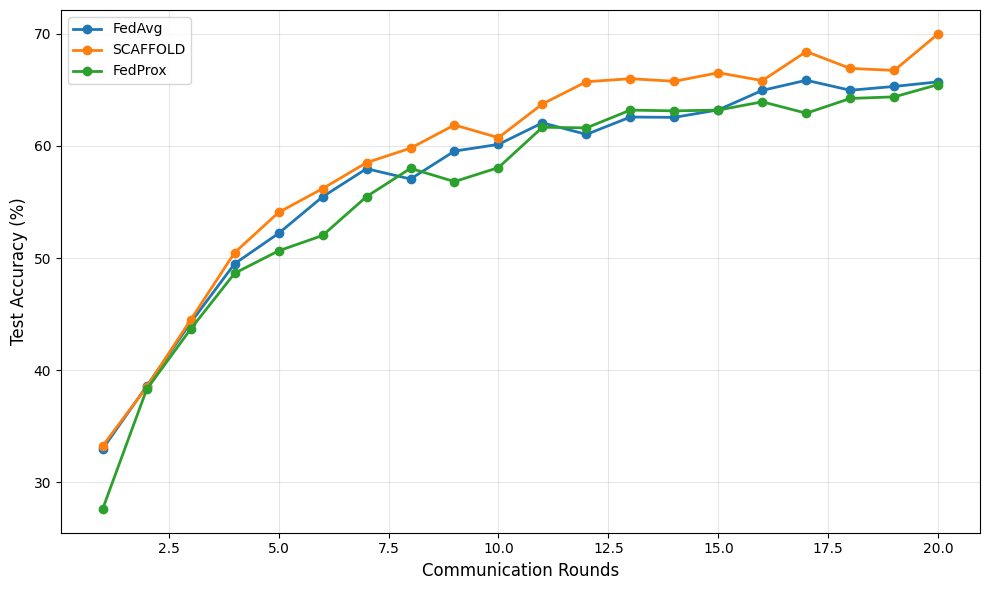

✓ Accuracy plot saved to: ./results/task4_2_scaffold_accuracy.png
Figure saved to ./results/task4_2_scaffold_loss.png


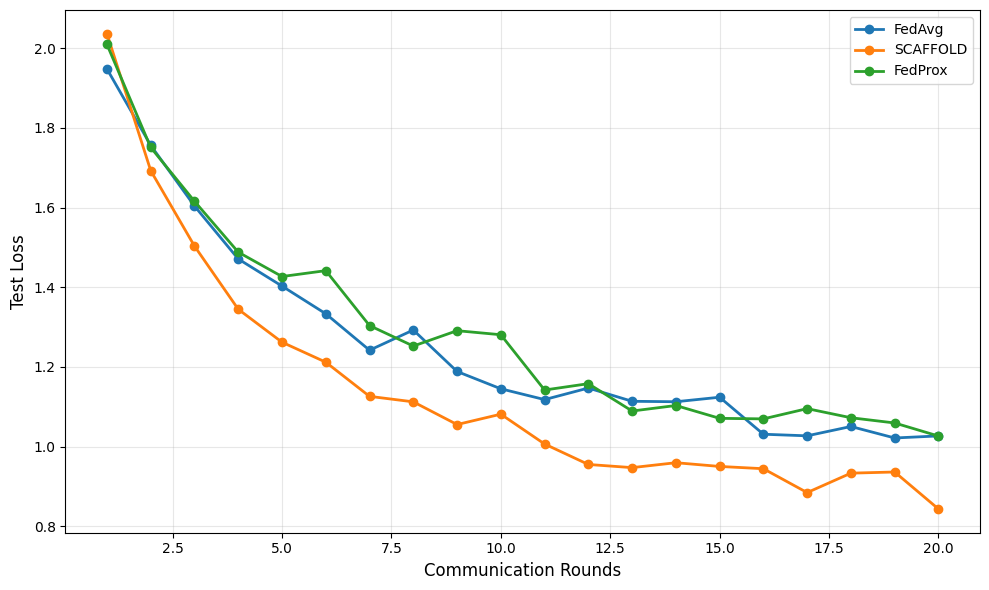

✓ Loss plot saved to: ./results/task4_2_scaffold_loss.png
✓ Detailed plot saved to: ./results/task4_2_scaffold_detailed.png


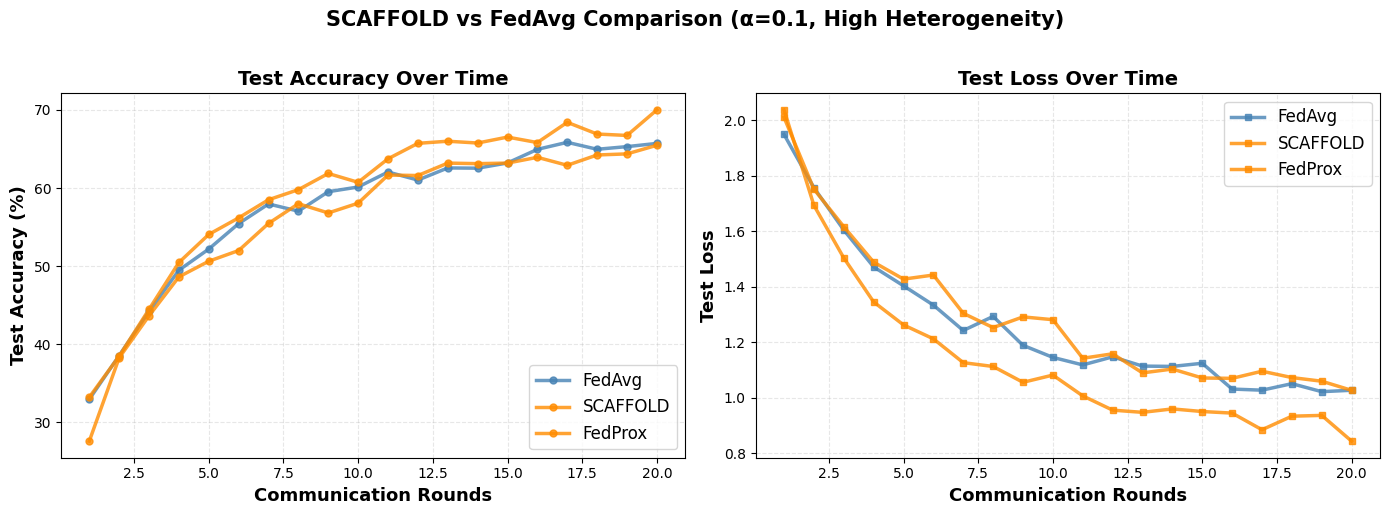

In [35]:
#%% Visualization: Comparison Plots
import matplotlib.pyplot as plt
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

# Plot 1: Test Accuracy Comparison
plot_comparison(results_comparison, metric='test_accuracy',
                title=f'SCAFFOLD vs FedAvg - Test Accuracy (α={CONFIG["alpha"]}, Non-IID)',
                save_path='./results/task4_2_scaffold_accuracy.png')
print("✓ Accuracy plot saved to: ./results/task4_2_scaffold_accuracy.png")

# Plot 2: Test Loss Comparison
plot_comparison(results_comparison, metric='test_loss',
                title=f'SCAFFOLD vs FedAvg - Test Loss (α={CONFIG["alpha"]}, Non-IID)',
                save_path='./results/task4_2_scaffold_loss.png')
print("✓ Loss plot saved to: ./results/task4_2_scaffold_loss.png")

# Plot 3: Detailed Side-by-Side Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Test Accuracy
for method_name, results in results_comparison.items():
    history = results['history']
    color = 'steelblue' if method_name == 'FedAvg' else 'darkorange'
    axes[0].plot(history['rounds'], history['test_accuracy'],
                marker='o', label=method_name, linewidth=2.5,
                markersize=5, color=color, alpha=0.8)

axes[0].set_xlabel('Communication Rounds', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
axes[0].set_title('Test Accuracy Over Time', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=12, loc='lower right')
axes[0].grid(True, alpha=0.3, linestyle='--')

# Subplot 2: Test Loss
for method_name, results in results_comparison.items():
    history = results['history']
    color = 'steelblue' if method_name == 'FedAvg' else 'darkorange'
    axes[1].plot(history['rounds'], history['test_loss'],
                marker='s', label=method_name, linewidth=2.5,
                markersize=5, color=color, alpha=0.8)

axes[1].set_xlabel('Communication Rounds', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Test Loss', fontsize=13, fontweight='bold')
axes[1].set_title('Test Loss Over Time', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=12, loc='upper right')
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.suptitle(f'SCAFFOLD vs FedAvg Comparison (α={CONFIG["alpha"]}, High Heterogeneity)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./results/task4_2_scaffold_detailed.png', dpi=300, bbox_inches='tight')
print("✓ Detailed plot saved to: ./results/task4_2_scaffold_detailed.png")
plt.show()


In [36]:
#%% Summary Statistics

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print_summary(results_comparison)

# Compute improvements
accuracy_improvement = (history_scaffold['test_accuracy'][-1] -
                       history_fedavg['test_accuracy'][-1])
best_accuracy_improvement = (max(history_scaffold['test_accuracy']) -
                            max(history_fedavg['test_accuracy']))

print("\n" + "="*80)
print("KEY FINDINGS")
print("="*80)

print(f"\n📊 Performance Improvement:")
print(f"   • Final Accuracy Gain: +{accuracy_improvement:.2f}% over FedAvg")
print(f"   • Best Accuracy Gain:  +{best_accuracy_improvement:.2f}% over FedAvg")

print(f"\n🔬 SCAFFOLD Algorithm Details:")
print(f"   • Gradient correction: g_i(y_i) - c_i + c")
print(f"   • Control update: c_i^+ = c_i - c + 1/(K*η_l)*(x - y_i)")
print(f"   • Server aggregation: c ← c + (|S|/N)*Δc̄")

print(f"\n💡 Key Advantages:")
print(f"   • Corrects client drift using variance reduction")
print(f"   • Particularly effective under high heterogeneity (α={CONFIG['alpha']})")
print(f"   • Theoretically removes effect of data heterogeneity")
print(f"   • Converges faster and to better solutions than FedAvg")

print(f"\n⚠️  Trade-offs:")
print(f"   • Communication overhead: 2× (sends model + control variate)")
print(f"   • Memory overhead: stores control variates on clients and server")
print(f"   • Complexity: requires careful implementation of control updates")

# Convergence speed analysis
target_accuracy = 60.0
rounds_to_target = {}

for method_name, results in results_comparison.items():
    history = results['history']
    for round_idx, acc in enumerate(history['test_accuracy']):
        if acc >= target_accuracy:
            rounds_to_target[method_name] = round_idx + 1
            break
    if method_name not in rounds_to_target:
        rounds_to_target[method_name] = "Did not reach target"

print(f"\n⏱️  Convergence Speed (rounds to reach {target_accuracy}% accuracy):")
for method, rounds in rounds_to_target.items():
    print(f"   • {method}: {rounds}")

if all(isinstance(r, int) for r in rounds_to_target.values()):
    speedup = rounds_to_target['FedAvg'] / rounds_to_target['SCAFFOLD']
    print(f"   • SCAFFOLD speedup: {speedup:.2f}× faster")


SUMMARY STATISTICS

EXPERIMENTAL RESULTS SUMMARY

FedAvg:
  Final Test Accuracy: 65.72%
  Best Test Accuracy:  65.86%
  Final Test Loss:     1.0270
  Final Divergence: 1.2885
  Average Divergence: 1.3702
  Configuration:
    dataset: cifar10
    num_clients: 5
    num_rounds: 20
    local_epochs: 5
    batch_size: 32
    lr_local: 0.01
    lr_global: 0.1
    momentum: 0.0
    alpha: 0.1
    device: cuda
    method: FedAvg

SCAFFOLD:
  Final Test Accuracy: 70.01%
  Best Test Accuracy:  70.01%
  Final Test Loss:     0.8436
  Final Divergence: 0.0000
  Average Divergence: 0.0000
  Configuration:
    dataset: cifar10
    num_clients: 5
    num_rounds: 20
    local_epochs: 5
    batch_size: 32
    lr_local: 0.01
    lr_global: 1.0
    momentum: 0.0
    alpha: 0.1
    device: cuda
    method: SCAFFOLD

FedProx:
  Final Test Accuracy: 65.48%
  Best Test Accuracy:  65.48%
  Final Test Loss:     1.0267
  Final Divergence: 1.2829
  Average Divergence: 1.3150
  Configuration:
    dataset: cifar1

In [37]:
#%% Final Summary Table

print("\n" + "="*80)
print("FINAL COMPARISON TABLE")
print("="*80)

print(f"\n{'Method':<15} {'Final Acc (%)':<15} {'Best Acc (%)':<15} {'Final Loss':<15}")
print("-" * 60)

for method_name, results in results_comparison.items():
    history = results['history']
    final_acc = history['test_accuracy'][-1]
    best_acc = max(history['test_accuracy'])
    final_loss = history['test_loss'][-1]

    print(f"{method_name:<15} {final_acc:<15.2f} {best_acc:<15.2f} {final_loss:<15.4f}")

print("-" * 60)
print(f"{'Improvement':<15} {f'+{accuracy_improvement:.2f}':<15} "
      f"{f'+{best_accuracy_improvement:.2f}':<15} {'—':<15}")


FINAL COMPARISON TABLE

Method          Final Acc (%)   Best Acc (%)    Final Loss     
------------------------------------------------------------
FedAvg          65.72           65.86           1.0270         
SCAFFOLD        70.01           70.01           0.8436         
FedProx         65.48           65.48           1.0267         
------------------------------------------------------------
Improvement     +4.29           +4.15           —              
